In [1]:
# Task Name: Time-Series-Based Pomegranate Fruit Disease Prediction
# Objective: To predict whether a specific fruit will develop a disease in the coming week, based on its images and environmental data from the preceding several weeks.
# Inputs:

# Image Sequence: [img_week1, img_week2, ..., img_week_t] (RGB)
# Environmental Sequence: [env_week1, env_week2, ..., env_week_t] (11 dimensions per frame)

# Output: Status for week_{t+1}: 0 (healthy) or 1 (diseased)

BiGRU: EfficientNet-B0 (prefetch) + 2-layer BiGRU + MLP
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 
Extracting: 100%|██████████| 46/46 [03:41<00:00,  4.82s/it]


  train: 1891 (H=757, D=1134, ratio=60.0%)
  val  : 410 (H=123, D=287, ratio=70.0%)
  test : 332 (H=134, D=198, ratio=59.6%)

  Params: 215,361 | pos_weight: 0.67

  Ep   TrLoss   VaLoss    TrF1    VaF1   TrAUC   VaAUC
--------------------------------------------------------
   1   0.5267   0.4602   0.706   0.752   0.670   0.781 ⭐
   2   0.4527   0.4049   0.758   0.798   0.791   0.808 ⭐
   3   0.4255   0.4705   0.767   0.684   0.811   0.813 ⭐
   4   0.3912   0.4185   0.788   0.770   0.846   0.830 ⭐
   5   0.3766   0.3976   0.805   0.781   0.859   0.853 ⭐
   6   0.3516   0.3886   0.822   0.785   0.879   0.861 ⭐
  10   0.3082   0.3624   0.840   0.841   0.907   0.854
  15   0.2711   0.4195   0.865   0.768   0.929   0.858
  20   0.2435   0.4134   0.884   0.788   0.944   0.848

Early stopping at epoch 21

Test (best val AUC = 0.861)

  Loss: 0.3825 | F1: 0.767 | AUC: 0.861

              precision    recall  f1-score   support

     Healthy       0.64      0.92      0.76       134
    Disea

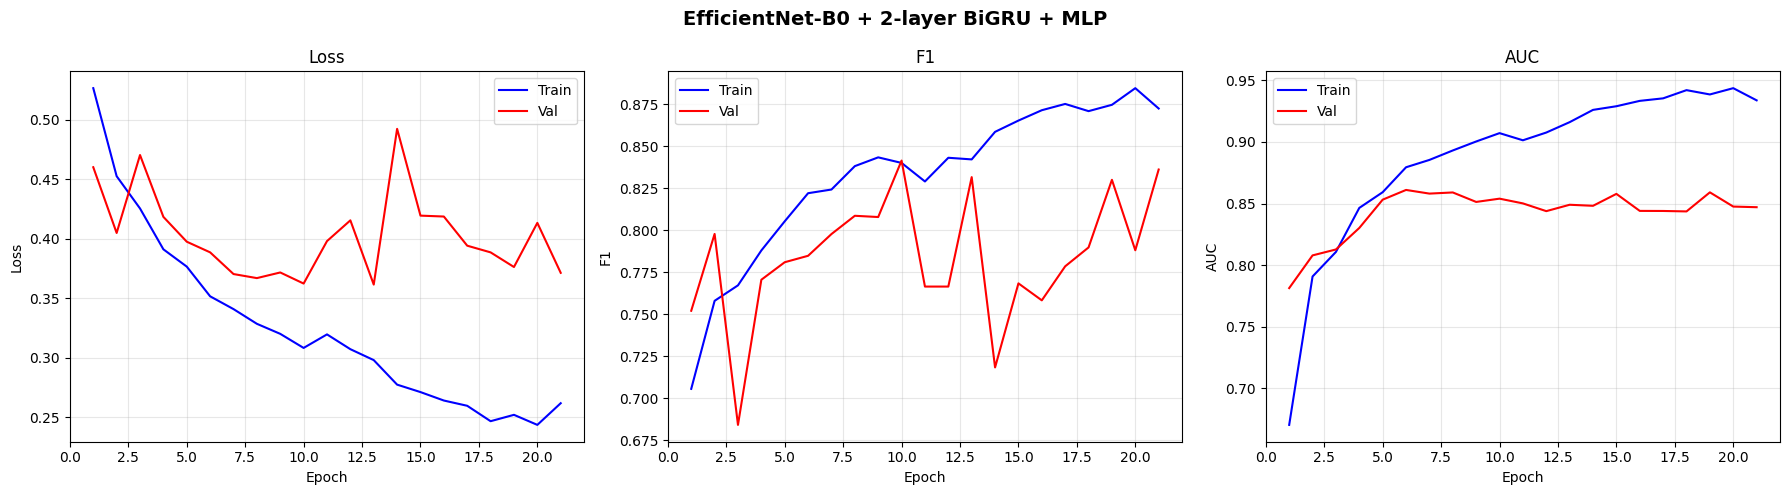

Saved bigru_curves.png

Prediction Examples (Test Set)


Extracting: 100%|██████████| 46/46 [03:37<00:00,  4.73s/it]



3_1 (Tree 3)
   Ground truth: W1:H W2:D W3:H W4:H W5:H W6:D W7:D W8:H W9:H W10:H W11:D W12:D W13:D W14:D
   Input                  → Target    P(D)      Pred    
   -------------------------------------------------------
   W 1-W 1 ( 1w) → W 2     D    0.174   Healthy  ✗
   W 1-W 2 ( 2w) → W 3     H    0.136   Healthy  ✓
   W 1-W 3 ( 3w) → W 4     H    0.222   Healthy  ✓
   W 1-W 4 ( 4w) → W 5     H    0.323   Healthy  ✓
   W 1-W 5 ( 5w) → W 6     D    0.211   Healthy  ✗
   W 1-W 6 ( 6w) → W 7     D    0.352   Healthy  ✗
   W 1-W 7 ( 7w) → W 8     H    0.255   Healthy  ✓
   W 1-W 8 ( 8w) → W 9     H    0.193   Healthy  ✓
   W 1-W 9 ( 9w) → W10     H    0.203   Healthy  ✓
   W 1-W10 (10w) → W11     D    0.592  Diseased  ✓
   W 1-W11 (11w) → W12     D    0.697  Diseased  ✓
   W 1-W12 (12w) → W13     D    0.725  Diseased  ✓
   W 1-W13 (13w) → W14     D    0.666  Diseased  ✓

3_2 (Tree 3)
   Ground truth: W1:H W2:H W3:D W4:D W5:D W6:D W7:D W8:D W9:D W10:D W11:D W12:D W13:D W14:D
   Input 

In [2]:
"""
EfficientNet-B0 (frozen, prefetch) + 2-layer BiGRU + MLP
Task: Input: Weeks 1 through t → Predict: Week t+1 Label (0/1)
"""

import random, warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from torchvision import transforms, models
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# Config
# ============================================================
MASTER_CSV = "/kaggle/input/datasets/minminandy/timeseries-table/master_timeseries.csv"
DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16
SEED = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

ENV_COLS = ['temp','dewpt','rh','precip_rate','solar_rad','ghi','dhi','dni','pres','wind_spd','vis']
FEAT_DIM = 1280
IN_DIM = FEAT_DIM + len(ENV_COLS)  # 1291
TREE_SPLIT = {'train': {'1','2','5','6','7','9'}, 'val': {'4','10'}, 'test': {'3','8'}}

# ============================================================
# Feature Extraction (Same as baseline; reused.)
# ============================================================
class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.transform(Image.open(self.paths[i]).convert("RGB"))

@torch.no_grad()
def extract_features(df):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    backbone.classifier = nn.Identity()
    backbone.to(DEVICE, dtype=DTYPE).eval()

    loader = DataLoader(ImageDataset(df['image_path'].tolist()),
                        batch_size=64, num_workers=4, pin_memory=True)
    feats = torch.cat([backbone(b.to(DEVICE, dtype=DTYPE)).float().cpu() for b in tqdm(loader, desc="Extracting")])

    del backbone; torch.cuda.empty_cache()

    feat_dict = {}
    for i, (_, row) in enumerate(df.iterrows()):
        feat_dict[(row['fruit_id'], int(row['week']))] = feats[i]
    return feat_dict

# ============================================================
# Sequence Dataset (preserve temporal order, no mean pooling)
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, samples, augment=False, drop_prob=0.2, noise_std=0.05):
        self.samples = samples  # list of (seq_tensor, label)
        self.augment = augment
        self.drop_prob = drop_prob
        self.noise_std = noise_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq, label = self.samples[i]

        if self.augment and len(seq) > 1:
            # Random frame drop: each frame is dropped with drop_prob, but at least 1 frame is kept
            mask = torch.rand(len(seq)) > self.drop_prob
            if mask.sum() == 0:
                mask[torch.randint(len(seq), (1,))] = True
            seq = seq[mask]

            # Feature noise injection
            seq = seq + torch.randn_like(seq) * self.noise_std

        return seq, label

def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    T_max = lengths.max().item()
    D = seqs[0].shape[-1]

    padded = torch.zeros(len(batch), T_max, D)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s

    return padded, torch.tensor(labels, dtype=torch.float32), lengths

# ============================================================
# Data Preparation
# ============================================================
def prepare_data(df, feat_dict):
    train_df = df[df['tree'].astype(str).isin(TREE_SPLIT['train'])]
    env_mean = train_df[ENV_COLS].mean().values.astype(np.float32)
    env_std  = train_df[ENV_COLS].std().values.astype(np.float32) + 1e-8

    env_dict = {}
    for _, row in df.iterrows():
        key = (row['fruit_id'], int(row['week']))
        vals = np.array([row[c] for c in ENV_COLS], dtype=np.float32)
        env_dict[key] = torch.tensor((vals - env_mean) / env_std)

    splits = {}
    for fid, grp in df.groupby('fruit_id'):
        grp = grp.sort_values('week')
        weeks = grp['week'].tolist()
        labels = dict(zip(grp['week'], grp['label']))
        tree = str(grp['tree'].iloc[0])
        split = next(k for k, v in TREE_SPLIT.items() if tree in v)

        for i in range(len(weeks) - 1):
            tl = labels[weeks[i + 1]]
            if tl == -1:
                continue
            input_weeks = weeks[:i + 1]
            # Each frame: concat(img_feat, env_feat) → (1291,)
            seq = torch.stack([
                torch.cat([feat_dict[(fid, w)], env_dict[(fid, w)]])
                for w in input_weeks
            ])  # (T, 1291)
            splits.setdefault(split, []).append((seq, float(tl)))

    datasets = {}
    for split in ['train', 'val', 'test']:
        datasets[split] = SeqDataset(splits[split], augment=(split == 'train'))
        n1 = int(sum(s[1] for s in splits[split]))
        n = len(splits[split])
        print(f"  {split:5s}: {n} (H={n-n1}, D={n1}, ratio={n1/n:.1%})")

    return datasets

# ============================================================
# Model: BiGRU (2-layer) + MLP
# ============================================================
class BiGRUClassifier(nn.Module):
    def __init__(self, in_dim=IN_DIM, proj=128, hidden=32, n_layers=2, drop=0.3):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj)
        self.gru = nn.GRU(
            input_size=proj,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=drop,
        )
        self.head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(hidden * 2, 1),
        )

    def forward(self, x, lengths):
        x = self.proj(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hn = self.gru(packed)
        out = torch.cat([hn[-2], hn[-1]], dim=-1)
        return self.head(out).squeeze(-1)

# ============================================================
# Training Utilities
# ============================================================
def calc_metrics(logits, labels):
    probs = torch.sigmoid(logits).numpy()
    return {'f1': f1_score(labels, probs > 0.5), 'auc': roc_auc_score(labels, probs)}

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_l, all_y, tot = [], [], 0
    for x, y, lengths in loader:
        x, y, lengths = x.to(DEVICE), y.to(DEVICE), lengths.to(DEVICE)
        l = model(x, lengths)
        tot += criterion(l, y).item() * len(y)
        all_l.append(l.cpu()); all_y.append(y.cpu())

    logits, labels = torch.cat(all_l), torch.cat(all_y)
    m = calc_metrics(logits, labels.numpy())
    m['loss'] = tot / len(labels)
    return m, (torch.sigmoid(logits).numpy() > 0.5).astype(float), labels.numpy()

# ============================================================
# Main
# ============================================================
def main():
    print("=" * 60)
    print("BiGRU: EfficientNet-B0 (prefetch) + 2-layer BiGRU + MLP")
    print("=" * 60)

    df = pd.read_csv(MASTER_CSV)

    # Step 1: extract
    feat_dict = extract_features(df)

    # Step 2: prepare
    datasets = prepare_data(df, feat_dict)
    del feat_dict

    loaders = {
        k: DataLoader(v, batch_size=128, shuffle=(k == 'train'), collate_fn=collate_fn)
        for k, v in datasets.items()
    }

    # Step 3: model
    model = BiGRUClassifier().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=7, factor=0.5)

    train_labels = torch.tensor([s[1] for s in datasets['train'].samples])
    n_pos = train_labels.sum().item()
    pos_weight = torch.tensor([(len(train_labels) - n_pos) / n_pos]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print(f"\n  Params: {sum(p.numel() for p in model.parameters()):,} | pos_weight: {pos_weight.item():.2f}\n")

    # Step 4: train
    hist = {k: [] for k in ['train_loss','val_loss','train_f1','val_f1','train_auc','val_auc']}
    best_auc, wait = 0, 0

    print(f"{'Ep':>4} {'TrLoss':>8} {'VaLoss':>8} {'TrF1':>7} {'VaF1':>7} {'TrAUC':>7} {'VaAUC':>7}")
    print("-" * 56)

    for ep in range(100):
        model.train()
        all_l, all_y, tot = [], [], 0
        for x, y, lengths in loaders['train']:
            x, y, lengths = x.to(DEVICE), y.to(DEVICE), lengths.to(DEVICE)
            logits = model(x, lengths)
            loss = criterion(logits, y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot += loss.item() * len(y)
            all_l.append(logits.detach().cpu()); all_y.append(y.cpu())

        tl, ty = torch.cat(all_l), torch.cat(all_y).numpy()
        tr = calc_metrics(tl, ty); tr['loss'] = tot / len(ty)

        vr, _, _ = evaluate(model, loaders['val'], criterion)
        scheduler.step(vr['auc'])

        for k in ['loss','f1','auc']:
            hist[f'train_{k}'].append(tr[k]); hist[f'val_{k}'].append(vr[k])

        mk = ""
        if vr['auc'] > best_auc:
            best_auc = vr['auc']; torch.save(model.state_dict(), "best_bigru.pt"); wait = 0; mk = " ⭐"
        else:
            wait += 1

        if (ep+1) % 5 == 0 or ep == 0 or mk:
            print(f"{ep+1:4d} {tr['loss']:8.4f} {vr['loss']:8.4f} "
                  f"{tr['f1']:7.3f} {vr['f1']:7.3f} {tr['auc']:7.3f} {vr['auc']:7.3f}{mk}")

        if wait >= 15:
            print(f"\nEarly stopping at epoch {ep+1}"); break

    # Step 5: test
    print(f"\n{'='*60}\nTest (best val AUC = {best_auc:.3f})")
    model.load_state_dict(torch.load("best_bigru.pt"))
    te, preds, labels = evaluate(model, loaders['test'], criterion)
    print(f"\n  Loss: {te['loss']:.4f} | F1: {te['f1']:.3f} | AUC: {te['auc']:.3f}")
    print(f"\n{classification_report(labels, preds, target_names=['Healthy','Diseased'])}")
    print(confusion_matrix(labels, preds))

    # Step 6: plot
    eps = range(1, len(hist['train_loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EfficientNet-B0 + 2-layer BiGRU + MLP", fontsize=14, fontweight='bold')
    for a, k, t in [(ax[0],'loss','Loss'), (ax[1],'f1','F1'), (ax[2],'auc','AUC')]:
        a.plot(eps, hist[f'train_{k}'], 'b-', label='Train')
        a.plot(eps, hist[f'val_{k}'], 'r-', label='Val')
        a.set_xlabel('Epoch'); a.set_ylabel(t); a.set_title(t); a.legend(); a.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig("bigru_curves.png", dpi=150, bbox_inches='tight'); plt.show()
    print("Saved bigru_curves.png")

    # Step 7: Show per-week predictions for test fruits
    print(f"\n{'='*85}")
    print("Prediction Examples (Test Set)")
    print(f"{'='*85}")

    # Rebuild feat_dict and env_dict for per-sample inference
    feat_dict = extract_features(df)
    train_df = df[df['tree'].astype(str).isin(TREE_SPLIT['train'])]
    env_mean = train_df[ENV_COLS].mean().values.astype(np.float32)
    env_std  = train_df[ENV_COLS].std().values.astype(np.float32) + 1e-8
    env_dict = {}
    for _, row in df.iterrows():
        key = (row['fruit_id'], int(row['week']))
        vals = np.array([row[c] for c in ENV_COLS], dtype=np.float32)
        env_dict[key] = torch.tensor((vals - env_mean) / env_std)

    test_fruits = sorted(df[df['tree'].astype(str).isin(TREE_SPLIT['test'])]['fruit_id'].unique())[:5]

    for fid in test_fruits:
        grp = df[df['fruit_id'] == fid].sort_values('week')
        weeks = grp['week'].tolist()
        labels_map = dict(zip(grp['week'], grp['label']))

        gt = " ".join([f"W{w}:{'H' if labels_map[w]==0 else 'D' if labels_map[w]==1 else '?'}" for w in weeks])
        print(f"\n{fid} (Tree {fid.split('_')[0]})")
        print(f"   Ground truth: {gt}")
        print(f"   {'Input':22s} → {'Target':>6s}  {'P(D)':>6s}  {'Pred':>8s}  {'':>2s}")
        print(f"   {'-'*55}")

        for i in range(len(weeks) - 1):
            tl = labels_map[weeks[i + 1]]
            if tl == -1:
                continue
            input_weeks = weeks[:i + 1]
            seq = torch.stack([
                torch.cat([feat_dict[(fid, w)], env_dict[(fid, w)]])
                for w in input_weeks
            ]).unsqueeze(0).to(DEVICE)
            lengths = torch.tensor([len(input_weeks)]).to(DEVICE)

            with torch.no_grad():
                prob = torch.sigmoid(model(seq, lengths)).item()

            true_str = "H" if tl == 0 else "D"
            pred_str = "Diseased" if prob > 0.5 else "Healthy"
            ok = "✓" if (prob > 0.5) == (tl == 1) else "✗"
            print(f"   W{input_weeks[0]:>2d}-W{input_weeks[-1]:>2d} ({len(input_weeks):>2d}w) → W{weeks[i+1]:>2d}  "
                  f"  {true_str:>2s}    {prob:.3f}  {pred_str:>8s}  {ok}")

    del feat_dict, env_dict

if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.2 MB/s eta 0:00:00
LNN-Stabilized: EfficientNet-B0 + 2-layer CfC (Liquid NN)


Extracting: 100%|██████████| 46/46 [03:34<00:00,  4.67s/it]


  train: 1891 (H=757, D=1134, ratio=60.0%)
  val  : 410 (H=123, D=287, ratio=70.0%)
  test : 332 (H=134, D=198, ratio=59.6%)

  Params: 239,681 | pos_weight: 0.67

  Ep   TrLoss   VaLoss    TrF1    VaF1   TrAUC   VaAUC
--------------------------------------------------------
   1   0.5354   0.4391   0.562   0.837   0.638   0.779 ⭐
   2   0.4834   0.5100   0.733   0.614   0.730   0.777
   3   0.4741   0.4158   0.734   0.792   0.747   0.816 ⭐
   4   0.4451   0.4177   0.782   0.814   0.775   0.804
   5   0.4325   0.5131   0.794   0.655   0.798   0.814
   6   0.4617   0.4403   0.730   0.740   0.766   0.831 ⭐
   7   0.4425   0.3960   0.738   0.824   0.771   0.834 ⭐
   8   0.4185   0.4313   0.794   0.795   0.796   0.818
   9   0.4176   0.4377   0.795   0.745   0.804   0.838 ⭐
  10   0.4134   0.4108   0.801   0.833   0.812   0.801
  11   0.4136   0.4869   0.801   0.769   0.814   0.837
  12   0.4270   0.3964   0.783   0.845   0.797   0.836
  13   0.4111   0.4375   0.822   0.848   0.811   0.830

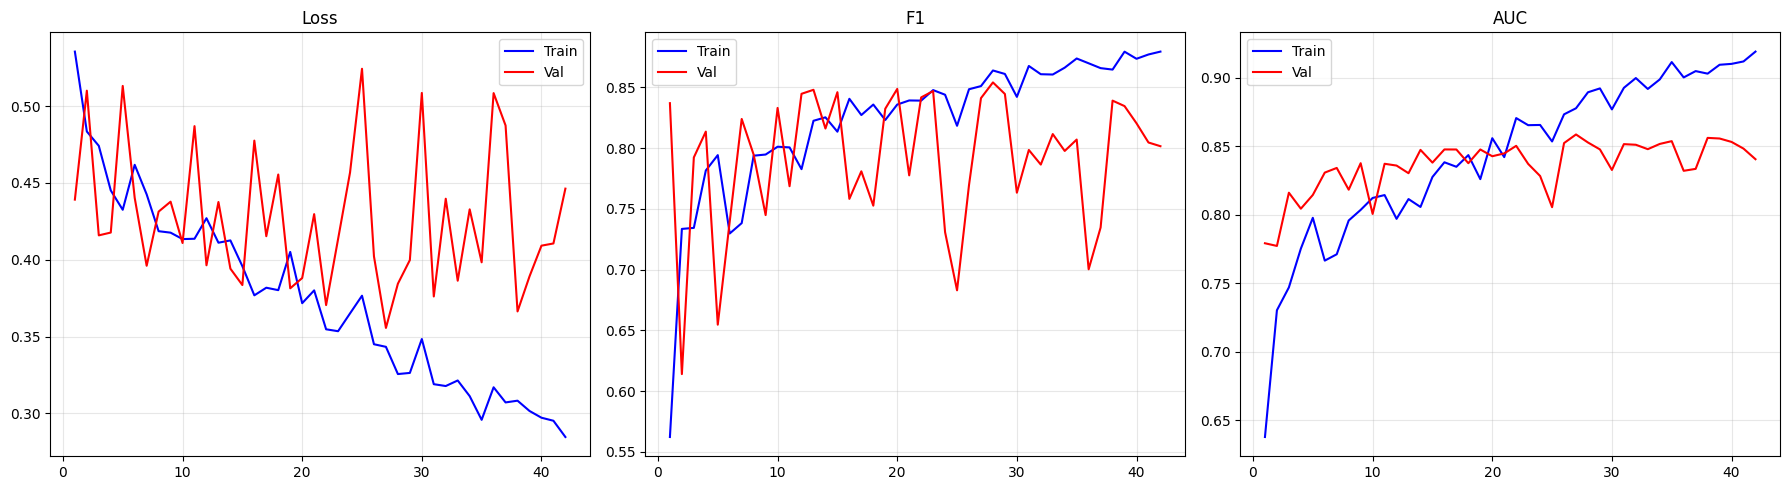

In [3]:
"""
Liquid Neural Network (LNN) Stabilized Version: 
EfficientNet-B0 (frozen) + 2-layer CfC (Liquid NN) + MLP
Task: Input: Weeks 1 through t → Predict: Week t+1 Label (0/1)
"""

import random, warnings, os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Ensure core library is installed
try:
    from ncps.torch import CfC
except ImportError:
    os.system('pip install ncps')
    from ncps.torch import CfC

warnings.filterwarnings("ignore")

# ============================================================
# Config
# ============================================================
MASTER_CSV = "/kaggle/input/datasets/minminandy/timeseries-table/master_timeseries.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16
SEED = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

ENV_COLS = ['temp','dewpt','rh','precip_rate','solar_rad','ghi','dhi','dni','pres','wind_spd','vis']
FEAT_DIM = 1280
IN_DIM = FEAT_DIM + len(ENV_COLS)  # 1291
TREE_SPLIT = {'train': {'1','2','5','6','7','9'}, 'val': {'4','10'}, 'test': {'3','8'}}

# ============================================================
# Feature Extraction (EfficientNet-B0)
# ============================================================
class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.transform(Image.open(self.paths[i]).convert("RGB"))

@torch.no_grad()
def extract_features(df):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    backbone.classifier = nn.Identity()
    backbone.to(DEVICE, dtype=DTYPE).eval()

    loader = DataLoader(ImageDataset(df['image_path'].tolist()),
                        batch_size=64, num_workers=4, pin_memory=True)
    feats = torch.cat([backbone(b.to(DEVICE, dtype=DTYPE)).float().cpu() for b in tqdm(loader, desc="Extracting")])

    del backbone; torch.cuda.empty_cache()

    feat_dict = {}
    for i, (_, row) in enumerate(df.iterrows()):
        feat_dict[(row['fruit_id'], int(row['week']))] = feats[i]
    return feat_dict

# ============================================================
# Sequence Dataset
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, samples, augment=False, drop_prob=0.2, noise_std=0.05):
        self.samples = samples
        self.augment = augment
        self.drop_prob = drop_prob
        self.noise_std = noise_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq, label = self.samples[i]
        if self.augment and len(seq) > 1:
            mask = torch.rand(len(seq)) > self.drop_prob
            if mask.sum() == 0: mask[torch.randint(len(seq), (1,))] = True
            seq = seq[mask]
            seq = seq + torch.randn_like(seq) * self.noise_std
        return seq, label

def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    T_max = lengths.max().item()
    D = seqs[0].shape[-1]
    padded = torch.zeros(len(batch), T_max, D)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s
    return padded, torch.tensor(labels, dtype=torch.float32), lengths

# ============================================================
# Data Preparation
# ============================================================
def prepare_data(df, feat_dict):
    train_df = df[df['tree'].astype(str).isin(TREE_SPLIT['train'])]
    env_mean = train_df[ENV_COLS].mean().values.astype(np.float32)
    env_std  = train_df[ENV_COLS].std().values.astype(np.float32) + 1e-8

    env_dict = {}
    for _, row in df.iterrows():
        key = (row['fruit_id'], int(row['week']))
        vals = np.array([row[c] for c in ENV_COLS], dtype=np.float32)
        env_dict[key] = torch.tensor((vals - env_mean) / env_std)

    splits = {}
    for fid, grp in df.groupby('fruit_id'):
        grp = grp.sort_values('week')
        weeks = grp['week'].tolist()
        labels = dict(zip(grp['week'], grp['label']))
        tree = str(grp['tree'].iloc[0])
        split = next(k for k, v in TREE_SPLIT.items() if tree in v)

        for i in range(len(weeks) - 1):
            tl = labels[weeks[i + 1]]
            if tl == -1: continue
            input_weeks = weeks[:i + 1]
            seq = torch.stack([
                torch.cat([feat_dict[(fid, w)], env_dict[(fid, w)]])
                for w in input_weeks
            ])
            splits.setdefault(split, []).append((seq, float(tl)))

    datasets = {}
    for split in ['train', 'val', 'test']:
        datasets[split] = SeqDataset(splits[split], augment=(split == 'train'))
        n1 = int(sum(s[1] for s in splits[split]))
        n = len(splits[split])
        print(f"  {split:5s}: {n} (H={n-n1}, D={n1}, ratio={n1/n:.1%})")
    return datasets

# ============================================================
# Model: LNN (Using CfC Cell) + MLP
# ============================================================
class LNNClassifier(nn.Module):
    def __init__(self, in_dim=IN_DIM, proj=128, hidden=32, n_layers=2, drop=0.3):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj)
        
        # CfC implements the liquid network
        self.lnn = CfC(
            input_size=proj,
            units=hidden * 2, 
            proj_size=None,
            return_sequences=False, 
            batch_first=True,
            backbone_layers=n_layers,
            backbone_dropout=drop,
        )
        
        self.head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(hidden * 2, 1),
        )

    def forward(self, x, lengths):
        x = self.proj(x)
        # Unpack tuple (output, hidden_state)
        out, _ = self.lnn(x) 
        return self.head(out).squeeze(-1)

# ============================================================
# Utilities
# ============================================================
def calc_metrics(logits, labels):
    probs = torch.sigmoid(logits).numpy()
    return {'f1': f1_score(labels, probs > 0.5), 'auc': roc_auc_score(labels, probs)}

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_l, all_y, tot = [], [], 0
    for x, y, lengths in loader:
        x, y, lengths = x.to(DEVICE), y.to(DEVICE), lengths.to(DEVICE)
        l = model(x, lengths)
        tot += criterion(l, y).item() * len(y)
        all_l.append(l.cpu()); all_y.append(y.cpu())

    logits, labels = torch.cat(all_l), torch.cat(all_y)
    m = calc_metrics(logits, labels.numpy())
    m['loss'] = tot / len(labels)
    return m, (torch.sigmoid(logits).numpy() > 0.5).astype(float), labels.numpy()

# ============================================================
# Main Training Loop (Stabilized)
# ============================================================
def main():
    print("=" * 60)
    print("LNN-Stabilized: EfficientNet-B0 + 2-layer CfC (Liquid NN)")
    print("=" * 60)

    df = pd.read_csv(MASTER_CSV)
    feat_dict = extract_features(df)
    datasets = prepare_data(df, feat_dict)
    del feat_dict

    loaders = {
        k: DataLoader(v, batch_size=128, shuffle=(k == 'train'), collate_fn=collate_fn)
        for k, v in datasets.items()
    }

    model = LNNClassifier(hidden=32).to(DEVICE)
    
    # Key optimization 1: Lower learning rate, increase L2 regularization
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

    train_labels = torch.tensor([s[1] for s in datasets['train'].samples])
    n_pos = train_labels.sum().item()
    pos_weight = torch.tensor([(len(train_labels) - n_pos) / (n_pos + 1e-6)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print(f"\n  Params: {sum(p.numel() for p in model.parameters()):,} | pos_weight: {pos_weight.item():.2f}\n")

    hist = {k: [] for k in ['train_loss','val_loss','train_f1','val_f1','train_auc','val_auc']}
    best_auc, wait = 0, 0

    print(f"{'Ep':>4} {'TrLoss':>8} {'VaLoss':>8} {'TrF1':>7} {'VaF1':>7} {'TrAUC':>7} {'VaAUC':>7}")
    print("-" * 56)

    for ep in range(100):
        model.train()
        all_l, all_y, tot = [], [], 0
        for x, y, lengths in loaders['train']:
            x, y, lengths = x.to(DEVICE), y.to(DEVICE), lengths.to(DEVICE)
            logits = model(x, lengths)
            loss = criterion(logits, y)
            
            optimizer.zero_grad()
            loss.backward()
            
            # Key optimization 2: Gradient clipping to prevent dynamical system collapse
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            tot += loss.item() * len(y)
            all_l.append(logits.detach().cpu()); all_y.append(y.cpu())

        tl, ty = torch.cat(all_l), torch.cat(all_y).numpy()
        tr = calc_metrics(tl, ty); tr['loss'] = tot / len(ty)
        vr, _, _ = evaluate(model, loaders['val'], criterion)
        scheduler.step(vr['auc'])

        for k in ['loss','f1','auc']:
            hist[f'train_{k}'].append(tr[k]); hist[f'val_{k}'].append(vr[k])

        mk = ""
        if vr['auc'] > best_auc:
            best_auc = vr['auc']; torch.save(model.state_dict(), "best_lnn_stable.pt"); wait = 0; mk = " ⭐"
        else: wait += 1

        # Print every epoch for easy monitoring of loss changes
        print(f"{ep+1:4d} {tr['loss']:8.4f} {vr['loss']:8.4f} "
              f"{tr['f1']:7.3f} {vr['f1']:7.3f} {tr['auc']:7.3f} {vr['auc']:7.3f}{mk}")

        if wait >= 15:
            print(f"\nEarly stopping at epoch {ep+1}"); break

    # --- Test ---
    print(f"\n{'='*60}\nTest Results (Best Val AUC = {best_auc:.3f})")
    model.load_state_dict(torch.load("best_lnn_stable.pt"))
    te, preds, labels = evaluate(model, loaders['test'], criterion)
    print(f"\n  Loss: {te['loss']:.4f} | F1: {te['f1']:.3f} | AUC: {te['auc']:.3f}")
    print(f"\n{classification_report(labels, preds, target_names=['Healthy','Diseased'])}")
    
    # --- Plot ---
    eps = range(1, len(hist['train_loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    for a, k, t in [(ax[0],'loss','Loss'), (ax[1],'f1','F1'), (ax[2],'auc','AUC')]:
        a.plot(eps, hist[f'train_{k}'], 'b-', label='Train')
        a.plot(eps, hist[f'val_{k}'], 'r-', label='Val')
        a.set_title(t); a.legend(); a.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig("stable_lnn_curves.png", dpi=150); plt.show()

if __name__ == "__main__":
    main()

In [4]:
import pandas as pd
import numpy as np
import os

def transform_drone_to_master_format(drone_path, master_path, output_name="drone_as_master.csv"):
    """
    Transform drone data into the standard 17-column format,
    fully syncing fruit_id, tree, and label from the master file.
    """
    # 1. Read Data
    df_drone = pd.read_excel(drone_path)
    df_master_ref = pd.read_csv(master_path) 
    
    num_rows = len(df_drone)
    
    # 2. Define 17 standard columns
    master_cols = [
        'fruit_id', 'tree', 'week', 'date', 'image_path', 'label', 
        'temp', 'dewpt', 'rh', 'precip_rate', 'solar_rad', 
        'ghi', 'dhi', 'dni', 'pres', 'wind_spd', 'vis'
    ]
    
    # 3. Create new DataFrame
    new_df = pd.DataFrame(index=np.arange(num_rows), columns=master_cols)
    
    # --- Core change: Sync identity and labels ---
    # Directly take the first num_rows rows from the reference file. If the reference file is shorter, wrap around cyclically.
    indices = np.arange(num_rows) % len(df_master_ref)
    
    # Sync fruit_id, tree, label and ensure correct types
    new_df['fruit_id'] = df_master_ref['fruit_id'].iloc[indices].values
    new_df['tree'] = df_master_ref['tree'].iloc[indices].values.astype(int)
    new_df['label'] = df_master_ref['label'].iloc[indices].values.astype(int)
    
    # 4. Fill time and other basic info
    new_df['week'] = np.arange(1, num_rows + 1)
    new_df['date'] = df_drone['datetime_et'].str.split('T').str[0] if 'datetime_et' in df_drone.columns else "2026-03-19"
    new_df['image_path'] = "" # Ensure empty string instead of NaN
    
    # 5. Core environmental data (Fahrenheit to Celsius)
    if 'corr_temp_F' in df_drone.columns:
        new_df['temp'] = (df_drone['corr_temp_F'] - 32) * 5 / 9
        
    if 'station_pressure_hPa' in df_drone.columns:
        new_df['pres'] = df_drone['station_pressure_hPa']
        
    # Fill other missing columns with 0
    cols_to_zero = ['dewpt', 'rh', 'precip_rate', 'solar_rad', 'ghi', 'dhi', 'dni', 'wind_spd', 'vis']
    new_df[cols_to_zero] = 0
    
    # 6. Final type conversion check before saving
    # Ensure no floating-point labels
    new_df['label'] = new_df['label'].astype(int)
    new_df['tree'] = new_df['tree'].astype(int)
    
    # Save
    new_df.to_csv(output_name, index=False)
    print(f"Conversion complete! Fully synced IDs and Labels from {master_path}.")
    print(f"Output file: {output_name} (rows: {new_df.shape[0]})")
    
    return new_df

# --- Execute ---
drone_path = "/kaggle/input/datasets/minminandy/test-datas/Copy of drone_mapping_data.xlsx"
master_ref_path = "/kaggle/input/datasets/minminandy/timeseries-table/master_timeseries.csv"

drone_master_df = transform_drone_to_master_format(drone_path, master_ref_path)

Conversion complete! Fully synced IDs and Labels from /kaggle/input/datasets/minminandy/timeseries-table/master_timeseries.csv.
Output file: drone_as_master.csv (rows: 683)


In [5]:
import os
import torch
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from torchvision import transforms, models
# Core: Import Liquid NN library
try:
    from ncps.torch import CfC
except ImportError:
    os.system('pip install ncps')
    from ncps.torch import CfC

# ============================================================
# 1. Config & Environment
# ============================================================
warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MASTER_CSV = "/kaggle/working/drone_as_master.csv"
# Use the stabilized LNN checkpoint path
CKPT_PATH = "/kaggle/working/best_lnn_stable.pt" 
OUTPUT_PATH = "/kaggle/working/inference_results_hourly.csv"

ENV_COLS = ['temp','dewpt','rh','precip_rate','solar_rad','ghi','dhi','dni','pres','wind_spd','vis']
TRAIN_TREES = {'1','2','5','6','7','9'}

# ============================================================
# 2. Architecture (must match the trained LNN)
# ============================================================
class LNNClassifier(torch.nn.Module):
    def __init__(self, in_dim=1291, proj=128, hidden=32, n_layers=2, drop=0.3):
        super().__init__()
        self.proj = torch.nn.Linear(in_dim, proj)
        # Replace GRU with CfC
        self.lnn = CfC(
            input_size=proj,
            units=hidden * 2,  # 64 dimensions, matching head input size
            proj_size=None,
            return_sequences=False, 
            batch_first=True,
            backbone_layers=n_layers,
            backbone_dropout=drop,
        )
        self.head = torch.nn.Sequential(
            torch.nn.Dropout(drop),
            torch.nn.Linear(hidden * 2, 1),
        )

    def forward(self, x, lengths=None):
        # 1. Projection layer
        x = self.proj(x)
        # 2. LNN processing (unpack tuple returned by CfC)
        out, _ = self.lnn(x) 
        # 3. Output
        return self.head(out).squeeze(-1)

# ============================================================
# 3. Core Inference Function
# ============================================================
@torch.no_grad()
def run_inference():
    print(f"Starting hourly inference with LNN on {DEVICE}...")
    
    if not os.path.exists(MASTER_CSV):
        print(f"❌ Error: {MASTER_CSV} not found.")
        return None

    # --- A. Data Loading ---
    df = pd.read_csv(MASTER_CSV)
    df['hour'] = (df['week'] * 168).astype(int) 
    
    train_data = df[df['tree'].astype(str).isin(TRAIN_TREES)][ENV_COLS]
    if len(train_data) == 0:
        train_data = df[ENV_COLS]
        
    env_mean = train_data.mean().values
    env_std = train_data.std().values + 1e-8

    # --- B. Image Feature Extraction ---
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    backbone.classifier = torch.nn.Identity()
    backbone.to(DEVICE).eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
    ])
    
    feat_dict = {}
    valid_mask = df['image_path'].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    valid_df = df[valid_mask]
    
    if len(valid_df) > 0:
        for _, row in tqdm(valid_df.iterrows(), desc="Extracting Images", total=len(valid_df)):
            img = transform(Image.open(row['image_path']).convert("RGB")).unsqueeze(0).to(DEVICE)
            feat_dict[(row['fruit_id'], row['hour'])] = backbone(img).cpu().squeeze()
    
    del backbone; torch.cuda.empty_cache()

    # --- C. Load LNN Model ---
    model = LNNClassifier().to(DEVICE).eval()
    if os.path.exists(CKPT_PATH):
        model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
        print(f"Loaded LNN checkpoint: {CKPT_PATH}")
    else:
        print(f"Warning: Checkpoint not found at {CKPT_PATH}")

    # --- D. Sequential Inference Logic ---
    results = []
    for fid, grp in tqdm(df.groupby('fruit_id'), desc="Predicting Hourly Sequences"):
        grp = grp.sort_values('hour').reset_index(drop=True)
        history_feats = []
        
        for i, row in grp.iterrows():
            h = row['hour']
            
            # 1. Image feature fallback
            img_feat = feat_dict.get((fid, h))
            if img_feat is None:
                prev_hours = [fh for (ffid, fh) in feat_dict.keys() if ffid == fid and fh < h]
                img_feat = feat_dict[(fid, max(prev_hours))] if prev_hours else torch.zeros(1280)
            
            # 2. Environmental feature processing
            env_vals = pd.to_numeric(row[ENV_COLS], errors='coerce').values
            env_vals = np.where(np.isnan(env_vals), env_mean, env_vals)
            env_feat = torch.tensor((env_vals - env_mean) / env_std, dtype=torch.float32)
            
            # Combine features
            history_feats.append(torch.cat([img_feat, env_feat]))
            
            # 3. Predict next hour
            if i < len(grp) - 1:
                target_row = grp.iloc[i+1]
                
                # Construct temporal sequence input
                seq = torch.stack(history_feats).unsqueeze(0).to(DEVICE)
                
                # Call LNN model for inference directly
                prob = torch.sigmoid(model(seq)).item()
                
                results.append({
                    'fruit_id': fid,
                    'input_until_hour': h,
                    'target_hour': target_row['hour'],
                    'prob': prob,
                    'pred': int(prob > 0.5),
                    'gt': target_row['label']
                })
                
    # --- E. Save Results ---
    res_df = pd.DataFrame(results)
    res_df.to_csv(OUTPUT_PATH, index=False)
    print(f"Success! Hourly LNN results saved to {OUTPUT_PATH}")
    return res_df

# ============================================================
# 4. Execution
# ============================================================
if __name__ == "__main__":
    results = run_inference()
    if results is not None:
        print("\nPreview of Hourly LNN Results:")
        print(results.head(10))

Starting hourly inference with LNN on cuda...
Loaded LNN checkpoint: /kaggle/working/best_lnn_stable.pt


Predicting Hourly Sequences: 100%|██████████| 57/57 [00:03<00:00, 16.56it/s]

Success! Hourly LNN results saved to /kaggle/working/inference_results_hourly.csv

Preview of Hourly LNN Results:
  fruit_id  input_until_hour  target_hour      prob  pred  gt
0     10_1               168          336  0.217846     0   0
1     10_1               336          504  0.142991     0   0
2     10_1               504          672  0.112159     0   0
3     10_1               672          840  0.091756     0   0
4     10_1               840         1008  0.078603     0   0
5     10_1              1008         1176  0.072269     0   0
6     10_1              1176         1344  0.069075     0   0
7     10_1              1344         1512  0.067258     0   0
8     10_1              1512         1680  0.066198     0   0
9     10_1              1680         1848  0.065975     0   0
